# Exploratory Data Analysis and Regression Modeling of California Housing Prices

## 1. Project Objective

The goal of this project is to demonstrate the Knowledge Discovery in Databases (KDD) process on a real-world dataset.
We apply data exploration, preprocessing, feature engineering, modeling, evaluation, and visualization to predict median house values in California using machine learning.

## 2. Dataset Description

We use the California Housing Prices dataset from Kaggle:
- Source: https://www.kaggle.com/camnugent/california-housing-prices
- Contains housing statistics for California districts derived from the 1990 census.
<br><br>Target Variable:<br>
- median_house_value<br>
<br>Features include:
- location (longitude, latitude),
- population statistics,
- median income,
- proximity to ocean, etc.

## 3. Load Dependencies

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 4. Data Loading and Exploration
<br><b>Load Dataset:<b>

In [12]:
cal_housing = pd.read_csv("housing.csv")

<b>View Sample Data:<b>

In [13]:
cal_housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<b>Dataset Overview:<b>

In [14]:
cal_housing.info()

# Shows column types, missing values, and memory usage.

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


<b>Statistical Summary:<b>

In [15]:
cal_housing.describe()

# Provides statistical measures (mean, std, min, max, quartiles).

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


<b>Feature Distributions:<b>

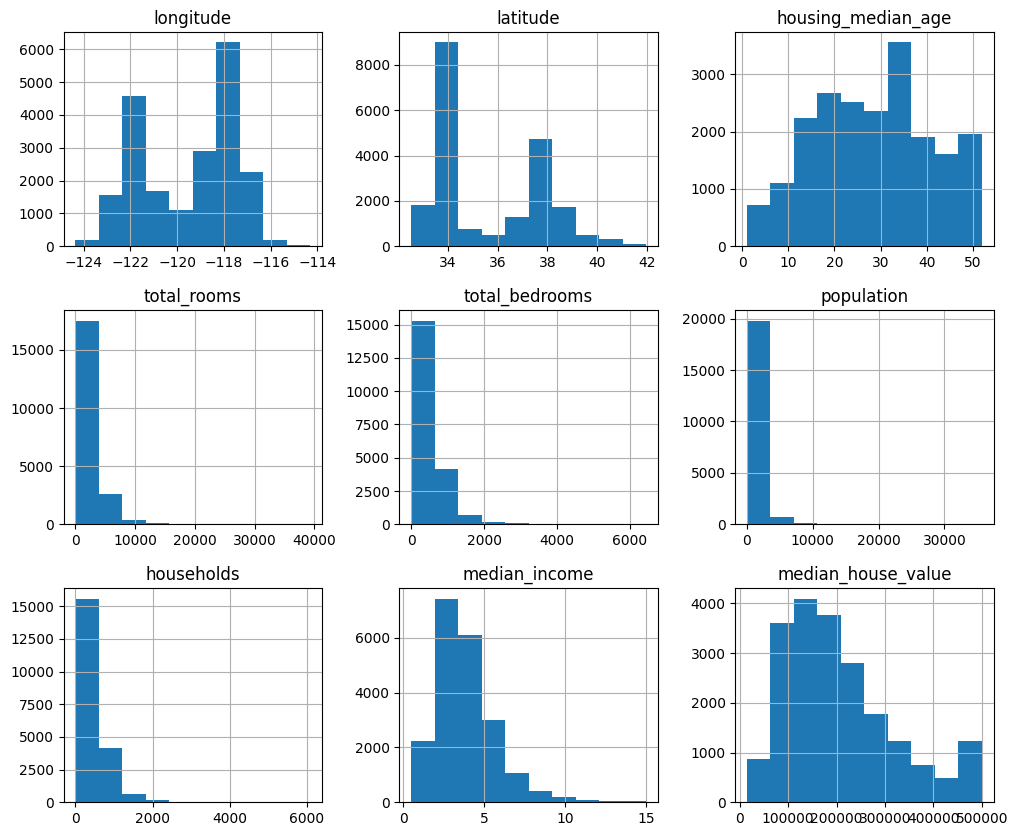

In [16]:
cal_housing.hist(figsize=(12,10))
plt.show()

# Visualizes distributions of numerical attributes.

<b>Categorical Feature Analysis:<b>

In [17]:
cal_housing['ocean_proximity'].value_counts()

# Displays frequency of categorical classes.

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

## 5. Data Cleaning and Preprocessing

<b>Missing Value Detection:<b>

In [18]:
cal_housing.isna().sum()

# Checks missing values. Only total_bedrooms contains missing entries.

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

<b>Remove Rows with Missing Values:<b>

In [19]:
cal_housing = cal_housing.dropna(axis=0)

# Removes rows containing missing values to ensure data consistency.

<b>One-Hot Encoding of Categorical Feature:<b>

In [20]:
cal_housing['ocean_proximity'] = cal_housing['ocean_proximity'].replace(
    'ISLAND', 'NEAR OCEAN'
)

one_hot = pd.get_dummies(cal_housing['ocean_proximity'])
cal_housing = pd.concat(
    [cal_housing.drop('ocean_proximity', axis=1), one_hot],
    axis=1
)

# Converts categorical values into numerical form.
# Merges rare category ISLAND into NEAR OCEAN.

## 6. Train-Test Split

In [21]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    cal_housing, test_size=0.2, random_state=0
)

# Splits data into 80% training and 20% testing.

<b>Separate Features and Target:<b>

In [22]:
X_train = train_set.drop('median_house_value', axis=1)
y_train = train_set['median_house_value']

X_test = test_set.drop('median_house_value', axis=1)
y_test = test_set['median_house_value']

## 7. Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = X_train.values
X_test = X_test.values

X_train[:,:-4] = scaler.fit_transform(X_train[:,:-4])
X_test[:,:-4] = scaler.transform(X_test[:,:-4])

# Normalizes numerical features for improved learning stability.

## 8. Model Training (Linear Regression)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# Trains a linear regression model for house price prediction.

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 9. Model Evaluation

In [ ]:
from sklearn.metrics import r2_score

train_score = r2_score(y_train, model.predict(X_train))
test_score = r2_score(y_test, model.predict(X_test))

train_score, test_score

# The model explains about 65% of variance, indicating good baseline performance.

(0.6442532623687187, 0.6526060502655654)

## 10. Visualization of Predictions

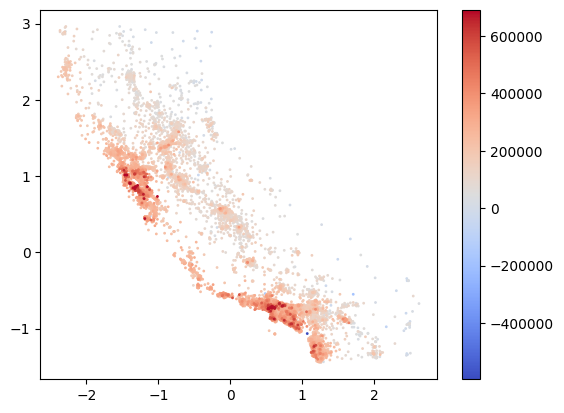

In [26]:
X_complete = np.concatenate([X_train, X_test], axis=0)
pred_complete = model.predict(X_complete)

order = np.argsort(pred_complete)

plt.scatter(
    X_complete[order,0],
    X_complete[order,1],
    c=pred_complete[order],
    cmap='coolwarm',
    s=1
)
plt.colorbar()
plt.show()

# Reveals California's geographical shape.
# Coastal and metropolitan areas show higher prices.

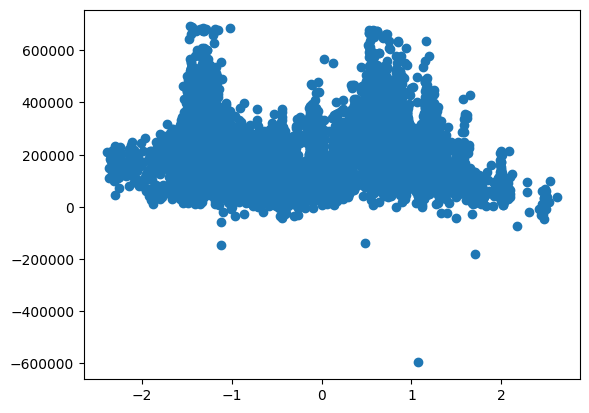

In [28]:
plt.scatter(X_complete[order,0],pred_complete[order])
plt.show()

It looks like the predictions are not linear w.r.t. latitude and longitude.
<br>The reason for that is that the other covariates are not fixed in these plots. Only if we keep them constant, we can expect linearly changing predictions.

## 11. Feature Importance Analysis

In [ ]:
feature_names = list(train_set.columns)
feature_names.remove('median_house_value')

{feature:coef for feature, coef in zip(feature_names, model.coef_)}

# Median income is the strongest predictor.
# Latitude and longitude strongly encode location-based price patterns.

{'longitude': np.float64(-55832.81156730253),
 'latitude': np.float64(-56282.93091664779),
 'housing_median_age': np.float64(13763.448496281824),
 'total_rooms': np.float64(-13002.703249137532),
 'total_bedrooms': np.float64(42964.3012853622),
 'population': np.float64(-40826.23955427717),
 'households': np.float64(15720.465404826065),
 'median_income': np.float64(74315.64275554982),
 '<1H OCEAN': np.float64(9688.353127480621),
 'INLAND': np.float64(-28468.372633384846),
 'NEAR BAY': np.float64(5711.628241209931),
 'NEAR OCEAN': np.float64(13068.391264694272)}

## 12. Experiment: Removing Location Features

In [29]:
model = LinearRegression()
model.fit(X_train[:,2:], y_train)

train_score = r2_score(y_train, model.predict(X_train[:,2:]))
test_score = r2_score(y_test, model.predict(X_test[:,2:]))

train_score, test_score

# Observation: Model performance barely decreases.
# Conclusion: Latitude and longitude mainly act as proxies for ocean proximity, 
# which is already encoded.

(0.6313447241585551, 0.6441061905410388)

## 13. Conclusion

This project successfully demonstrates the entire KDD pipeline:
- Data exploration
- Data cleaning
- Feature engineering
- Machine learning
- Evaluation
- Visualization

The results show:
- Median income is the dominant predictor.
- Geographic location plays a crucial role.
- Feature engineering significantly impacts model performance.